AXEL DANIEL NUÑO ARRIETA | T035859

### Exportación de un modelo de Machine Learning

Este proyecto se desarrolla como parte de la actividad **“Exportar un modelo de ML”**, cuyo objetivo es construir un flujo completo de machine learning que abarque desde el análisis exploratorio de datos hasta la exportación de un modelo entrenado listo para ser utilizado en un entorno externo.

Se utiliza un conjunto de datos de automóviles obtenido desde Kaggle, el cual permite abordar un problema de **regresión**, donde se busca predecir el precio de un vehículo en función de sus características técnicas y comerciales.

https://www.kaggle.com/datasets/syedaeman2212/global-cars-data

### Importación de librerías

En este bloque se importan las librerías necesarias para el análisis exploratorio de datos, visualización, preprocesamiento, entrenamiento del modelo, evaluación y exportación. Se emplean bibliotecas estándar de ciencia de datos como pandas, matplotlib, seaborn y scikit-learn, garantizando reproducibilidad y buenas prácticas.

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import joblib


### Carga del conjunto de datos

Se carga el conjunto de datos **Global Cars Dataset** desde un archivo CSV. Este dataset contiene información sintética sobre automóviles fabricados entre 2005 y 2025, incluyendo variables numéricas, categóricas y el precio del vehículo en dólares.

In [73]:
data = pd.read_csv('global_cars_dataset_synthetic.csv')

### Inspección inicial del dataset

Se realiza una exploración preliminar del conjunto de datos utilizando `data.info()` y `data.describe()`. Este análisis permite conocer la estructura del dataset, los tipos de datos, el número de registros, así como estadísticas descriptivas básicas de las variables numéricas.

In [74]:
data.info()
data.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Car_ID                 300 non-null    str  
 1   Brand                  300 non-null    str  
 2   Manufacture_Year       300 non-null    int64
 3   Body_Type              300 non-null    str  
 4   Fuel_Type              300 non-null    str  
 5   Transmission           300 non-null    str  
 6   Engine_CC              300 non-null    int64
 7   Horsepower             300 non-null    int64
 8   Mileage_km_per_l       300 non-null    int64
 9   Price_USD              300 non-null    int64
 10  Manufacturing_Country  300 non-null    str  
dtypes: int64(5), str(6)
memory usage: 25.9 KB


,count,mean,std,min,25%,50%,75%,max
Manufacture_Year,300.0,2015.123333,5.966023,2005.0,2010.00,2015.0,2020.00,2025.0
Engine_CC,300.0,3052.880000,1117.937497,1001.0,2074.00,3117.5,3964.00,4994.0
Horsepower,300.0,328.346667,153.202644,70.0,188.25,329.5,454.75,599.0
Mileage_km_per_l,300.0,19.716667,6.028061,10.0,15.00,19.5,24.00,30.0
Price_USD,300.0,60848.823333,34445.525598,5221.0,29418.50,59179.5,89692.25,119587.0


### Identificación de variables numéricas y categóricas

En este bloque se clasifican las variables del dataset en numéricas y categóricas. Esta separación es fundamental para aplicar transformaciones específicas durante el preprocesamiento y para construir un pipeline adecuado que evite errores de data leakage.

In [75]:
# Definimos las columnas numéricas y categóricas para el análisis
numerical_cols = [
    'Manufacture_Year',
    'Engine_CC',
    'Horsepower',
    'Mileage_km_per_l'
]

categorical_cols = [
    'Brand',
    'Body_Type',
    'Fuel_Type',
    'Transmission'
]
data[categorical_cols] = data[categorical_cols].astype(str)


### Análisis exploratorio de variables numéricas

Se analizan las distribuciones de las variables numéricas mediante histogramas con estimación de densidad. Este análisis permite identificar rangos, dispersión, posibles sesgos y valores extremos en variables como año de fabricación, cilindrada, potencia y rendimiento.

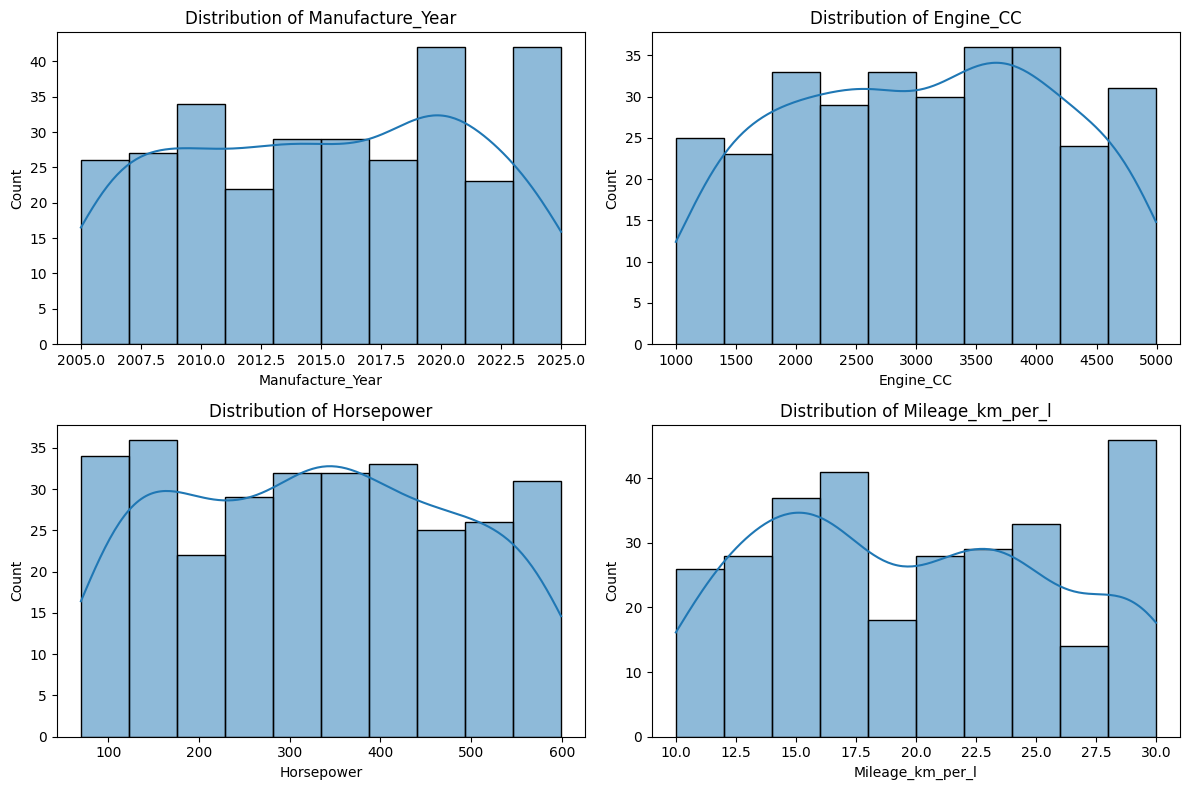

In [76]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axs.ravel(), numerical_cols):
    sns.histplot(data[col], kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')

plt.tight_layout()

### Distribución de la variable objetivo (Price_USD)

Se visualiza la distribución del precio de los vehículos para comprender su comportamiento general. Este paso es clave para validar el enfoque de regresión y detectar posibles asimetrías o concentraciones de valores.

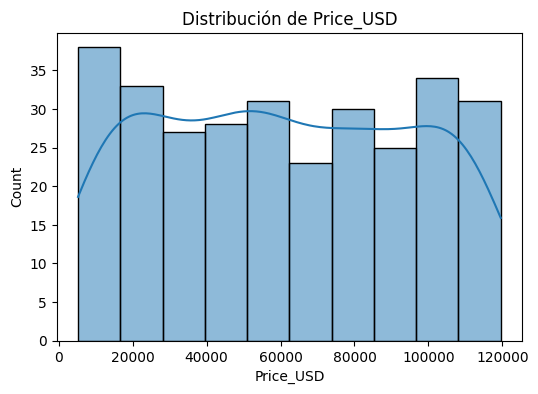

Duplicados: 0


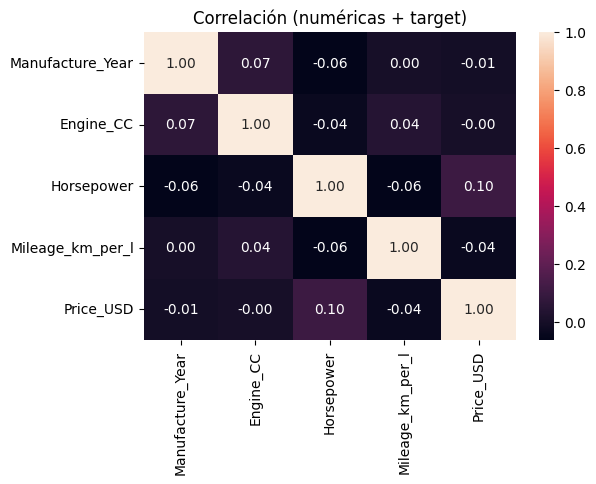

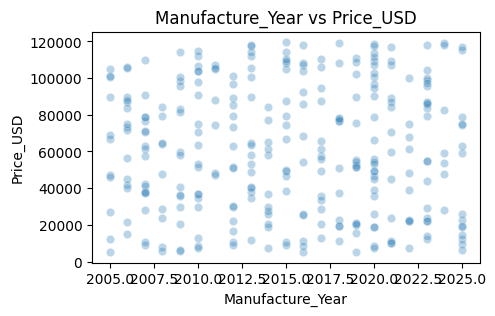

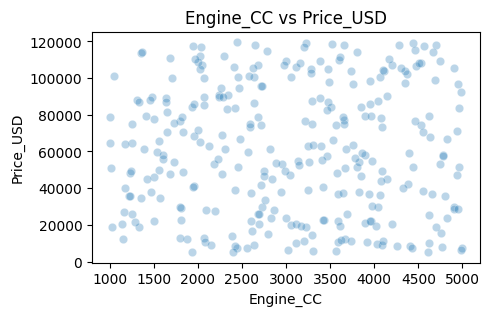

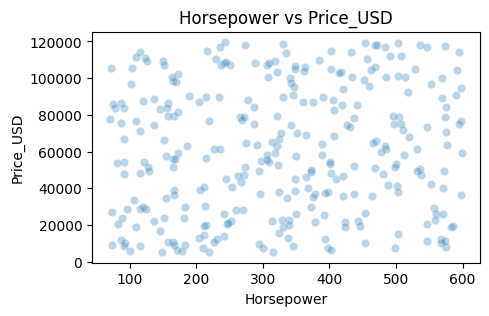

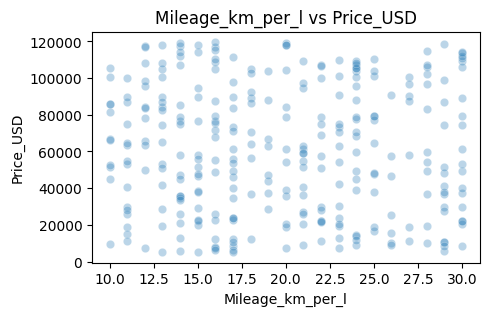

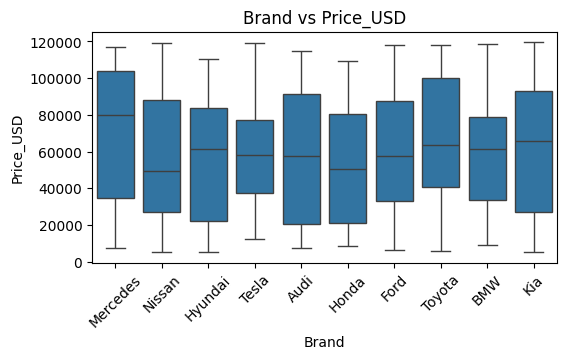

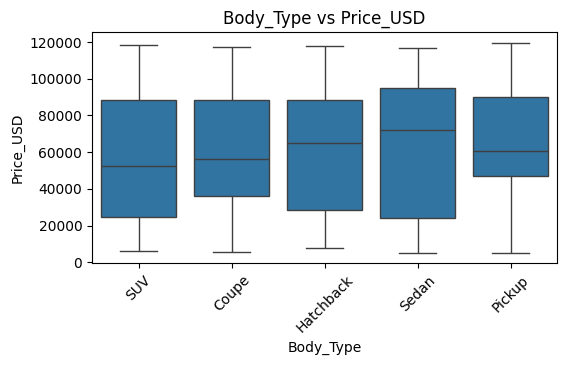

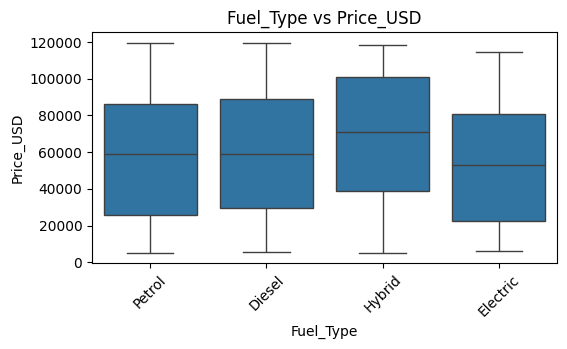

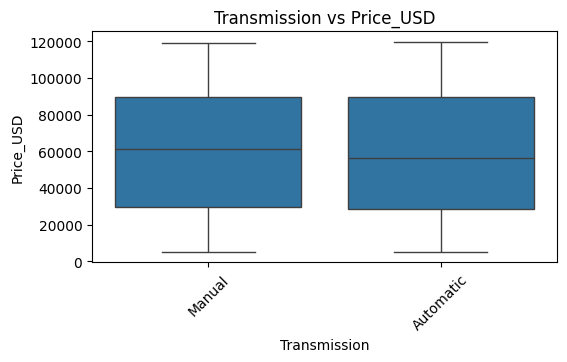

In [77]:
plt.figure(figsize=(6,4))
sns.histplot(data['Price_USD'], kde=True)
plt.title('Distribución de Price_USD')
plt.show()

print("Duplicados:", data.duplicated().sum())

plt.figure(figsize=(6,4))
sns.heatmap(data[numerical_cols + ['Price_USD']].corr(), annot=True, fmt=".2f")
plt.title("Correlación (numéricas + target)")
plt.show()

for col in numerical_cols:
    plt.figure(figsize=(5,3))
    sns.scatterplot(data=data, x=col, y='Price_USD', alpha=0.3)
    plt.title(f'{col} vs Price_USD')
    plt.show()

for col in categorical_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(data=data, x=col, y='Price_USD')
    plt.title(f'{col} vs Price_USD')
    plt.xticks(rotation=45)
    plt.show()

### Distribución de variables categóricas

Se analiza la distribución de las variables categóricas del conjunto de datos mediante gráficos de conteo. Este análisis permite observar la frecuencia de cada categoría en variables como la marca, el tipo de carrocería, el tipo de combustible y la transmisión. La revisión de estas distribuciones es importante para verificar el balance de las categorías y anticipar el impacto de la codificación One-Hot durante el preprocesamiento.

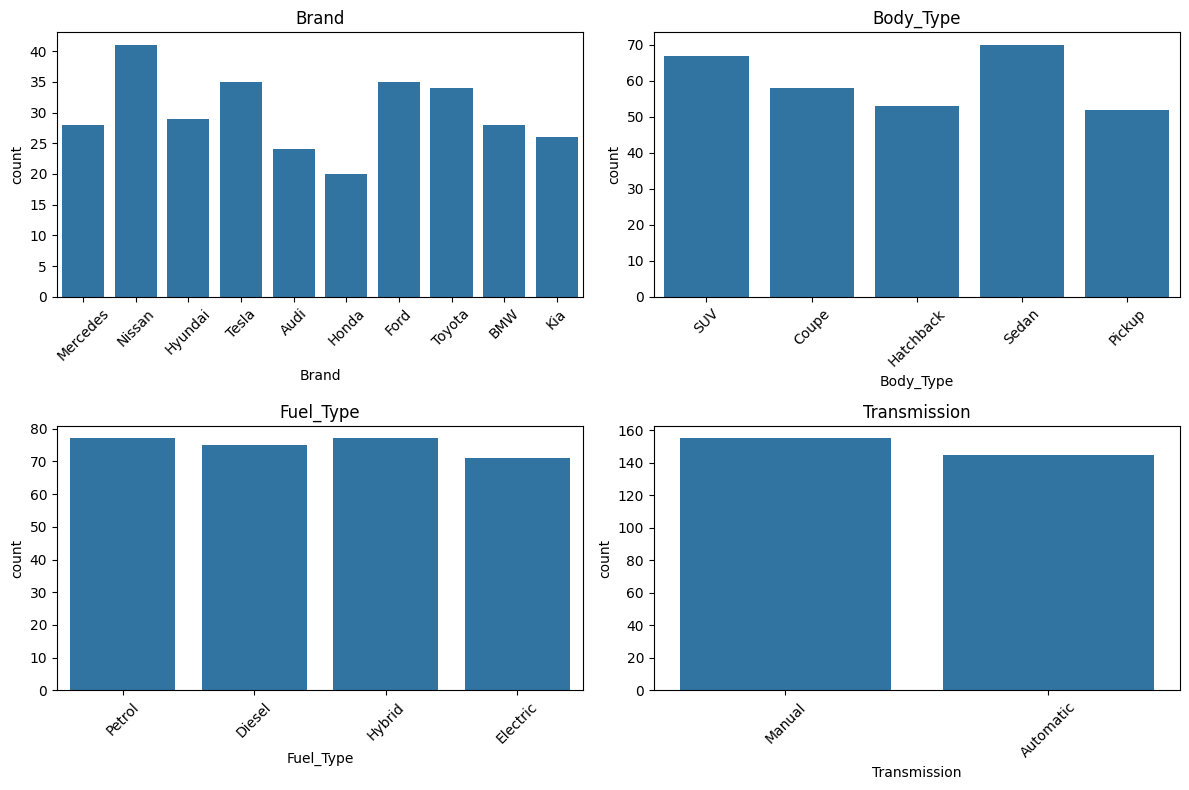

In [78]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axs.ravel(), categorical_cols):
    sns.countplot(data=data, x=col, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()

### Análisis de valores nulos y duplicados

Se evalúa la presencia de valores faltantes y registros duplicados en el conjunto de datos. Aunque el dataset no presenta valores nulos, este análisis se incluye como parte del EDA para documentar la calidad de los datos y justificar las decisiones de preprocesamiento.

Car_ID                   0.0
Brand                    0.0
Manufacture_Year         0.0
Body_Type                0.0
Fuel_Type                0.0
Transmission             0.0
Engine_CC                0.0
Horsepower               0.0
Mileage_km_per_l         0.0
Price_USD                0.0
Manufacturing_Country    0.0
dtype: float64

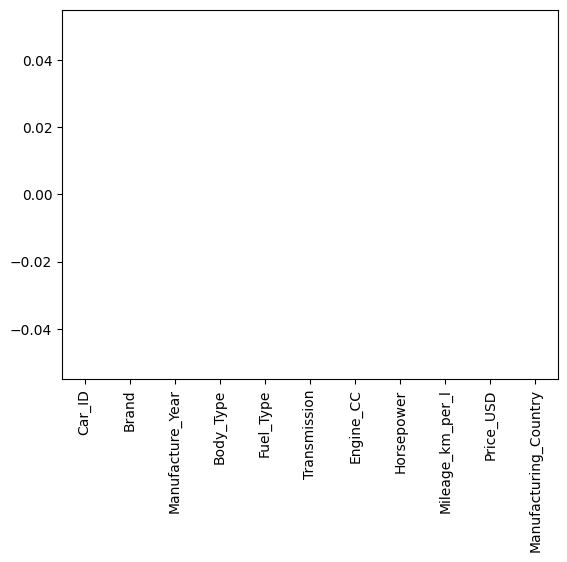

In [79]:
missing_counts = data.isnull().sum()
missing_counts.plot(kind='bar')

data.isnull().mean() * 100

### Pipeline de preprocesamiento

Se define un pipeline de preprocesamiento utilizando `ColumnTransformer`.  
- Las variables numéricas se imputan con la media y se estandarizan.  
- Las variables categóricas se imputan con la moda y se transforman mediante One-Hot Encoding.

Este enfoque permite encapsular todas las transformaciones y evitar inconsistencias entre entrenamiento e inferencia.

In [ ]:
# definimos el pipeline de preprocesamiento, con esto aplicamos transformaciones distintas según el tipo de variable 
#ya sea numérica o categórica
preprocessing_pipeline = ColumnTransformer(
    transformers=[
        # transf para variables numéricas.
        ('num', make_pipeline(
            # SimpleImputer con estrategia 'mean', se utiliza la media para manejar posibles valores faltantes en variables
            SimpleImputer(strategy='mean'),
            # StandardScaler, se aplica estandarización para que todas las variables numéricas
            # queden en una escala comparable, evitando que aquellas con valores más grandes influyan de forma desproporcionada en el modelo.
            StandardScaler()
        ), numerical_cols),
        
        # transf para variables categ
        # Estas columnas contienen información que debe transformars antes de poder ser utilizada por el modelo.
        ('cat', make_pipeline(
            
            # OneHotEncoder convierte las variables categóricas en columnas binarias para que
            # el modelo de regresión pueda interpretarlas correctamente.
            # El parámetro handle_unknown='ignore' evita errores si aparecen
            # categorías nuevas en el conjunto de prueba.
            OneHotEncoder(handle_unknown='ignore')
        ), categorical_cols)
    ]
)

### Separación de variables predictoras y variable objetivo

Se separan las variables independientes (características del vehículo) y la variable dependiente (`Price_USD`). Esta separación es necesaria para entrenar un modelo supervisado de regresión.

In [81]:
X = data[numerical_cols + categorical_cols]
y = data['Price_USD']

### División del conjunto de datos

El dataset se divide en conjuntos de entrenamiento y prueba utilizando una proporción 80/20. Esta partición permite evaluar el desempeño del modelo sobre datos no vistos.

In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Resultado del preprocesamiento

Se muestra el resultado del pipeline de preprocesamiento aplicado al conjunto de entrenamiento. Todas las variables quedan en formato numérico, listas para ser utilizadas por el modelo de regresión. BREVE NOTA: En el siguiente bloque se muestran los datos después de aplicar el pipeline de preprocesamiento. Las variables numéricas han sido estandarizadas, por lo que ahora se expresan en una escala común alrededor de la media, lo que explica la presencia de valores positivos y negativos. Esto permite que ninguna variable domine al modelo por su magnitud. Las variables categóricas fueron transformadas en columnas binarias mediante One-Hot Encoding, donde el valor 1 indica la presencia de una categoría específica y el 0 su ausencia. El resultado es un conjunto de datos completamente numérico, listo para ser utilizado por el modelo de regresión.

In [83]:
# aplicamos únicamente el pipeline de preprocesamiento al conjunto de entrenamiento
X_transformed = preprocessing_pipeline.fit_transform(X_train)

# obtenemos los nombres de las columnas numéricas (se mantienen igual)
num_features = numerical_cols

# obtenemos los nombres generados por OneHotEncoder para las variables categóricas
cat_features = preprocessing_pipeline.named_transformers_['cat'] \
    .named_steps['onehotencoder'] \
    .get_feature_names_out(categorical_cols)

# unimos todas las columnas finales (numéricas + categóricas codificadas)
all_features = list(num_features) + list(cat_features)

# convertimos el resultado en un DataFrame para poder visualizarlo mejor
X_transformed_df = pd.DataFrame(
    X_transformed.toarray() if hasattr(X_transformed, "toarray") else X_transformed,
    columns=all_features
)

X_transformed_df.head()

,Manufacture_Year,Engine_CC,Horsepower,Mileage_km_per_l,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Kia,...,Body_Type_Hatchback,Body_Type_Pickup,Body_Type_SUV,Body_Type_Sedan,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_Hybrid,Fuel_Type_Petrol,Transmission_Automatic,Transmission_Manual
0,1.632775,0.105647,-0.966359,0.226015,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.129453,0.501051,-0.609029,-0.611077,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,-0.705726,1.239668,0.047157,1.565361,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,0.964632,1.428081,-0.108769,0.728269,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
4,-0.872762,1.082214,0.534423,0.728269,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


### Construcción del modelo de Machine Learning

Se construye un modelo de regresión lineal integrado dentro de un pipeline junto con el preprocesamiento. Este enfoque garantiza un flujo de trabajo limpio, reproducible y fácil de exportar.

In [84]:
model = make_pipeline(
    preprocessing_pipeline,
    LinearRegression()
)

### Entrenamiento del modelo

En este bloque se entrena el modelo de regresión lineal utilizando el conjunto de entrenamiento. Durante este proceso, el pipeline aplica automáticamente todas las transformaciones definidas previamente.

In [85]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

### Evaluación del modelo

El desempeño del modelo se evalúa utilizando métricas de regresión: MAE, RMSE y R². Además, se analiza el comportamiento de los residuos para verificar posibles patrones o sesgos en las predicciones.

MAE:  29,273.93 USD
RMSE: 34,483.23 USD
R2:   0.0250


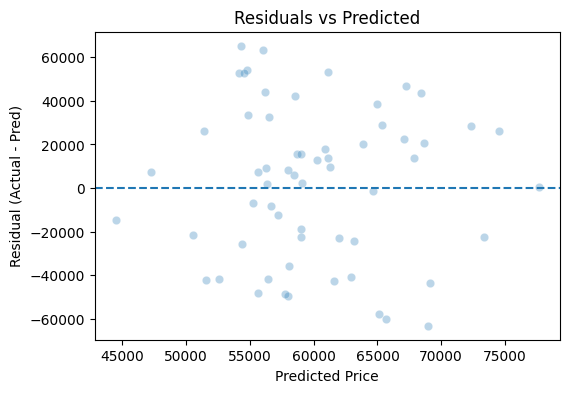

In [86]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:,.2f} USD")
print(f"RMSE: {rmse:,.2f} USD")
print(f"R2:   {r2:.4f}")

residuals = y_test - y_pred
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.3)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Predicted")
plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Pred)")
plt.show()

### Exportación del modelo entrenado

Finalmente, se exporta el pipeline completo (preprocesamiento + modelo entrenado) a un archivo utilizando `joblib`. Este archivo puede ser cargado posteriormente en un proyecto independiente para realizar inferencias sin necesidad de reentrenar el modelo.

In [87]:
joblib.dump(model, "car_price_model.joblib")

['car_price_model.joblib']

Lo ponemos a prueba

In [88]:
loaded_model = joblib.load("car_price_model.joblib")

sample = pd.DataFrame([{
    "Manufacture_Year": 2020,
    "Engine_CC": 2000,
    "Horsepower": 150,
    "Mileage_km_per_l": 14.5,
    "Brand": "Toyota",
    "Body_Type": "SUV",
    "Fuel_Type": "Petrol",
    "Transmission": "Automatic"
}])

pred = loaded_model.predict(sample)[0]
print("Predicción Price_USD:", pred)

Predicción Price_USD: 57969.23049587677


### Conclusión

En esta actividad se desarrolló un flujo completo de machine learning enfocado en la exportación de un modelo entrenado. A partir de un conjunto de datos de automóviles obtenido desde Kaggle, se realizó un análisis exploratorio de datos para comprender la estructura, distribución y relaciones entre las variables.

Posteriormente, se definió un pipeline de preprocesamiento que permitió tratar de forma adecuada las variables numéricas y categóricas, evitando problemas comunes como el data leakage. Sobre este pipeline se entrenó un modelo de regresión lineal, el cual fue evaluado utilizando métricas apropiadas para problemas de regresión.

Finalmente, el modelo completo fue exportado a un archivo serializado, permitiendo su reutilización en un proyecto independiente para realizar inferencias sobre nuevos datos. Este ejercicio demuestra la importancia de integrar el preprocesamiento y el modelo dentro de un solo pipeline, facilitando la portabilidad, reproducibilidad y despliegue de soluciones de machine learning en entornos reales.